# SHOAIB ALI KORI | 24I-2605 | DAV LAB 02

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

df = sns.load_dataset("penguins").dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


### TASK 01

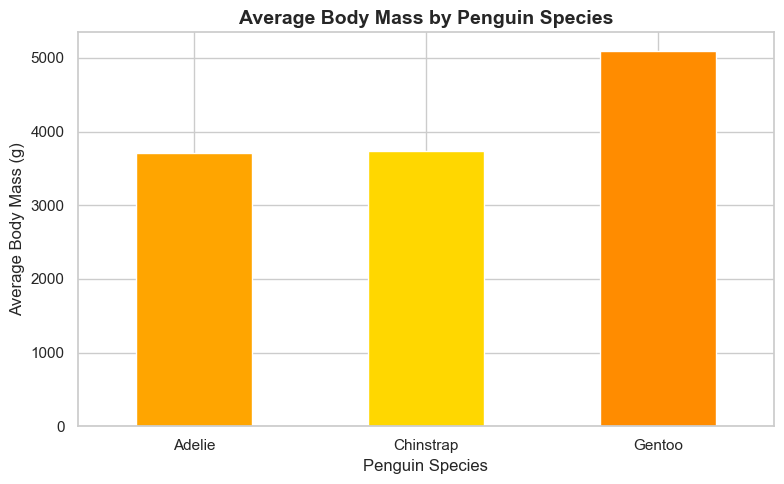

In [18]:
avg_body_mass = df.groupby('species')['body_mass_g'].mean()

avg_body_mass.plot(
    kind='bar',
    color=['orange', 'gold', 'darkorange', 'khaki'],
    figsize=(8, 5)
)

plt.xlabel('Penguin Species')
plt.ylabel('Average Body Mass (g)')
plt.title('Average Body Mass by Penguin Species', fontsize=14, fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### TASK 02

C:\Users\Shoaib Ali Kori\AppData\Local\Temp\ipykernel_24032\2655824848.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species', palette='Set1')


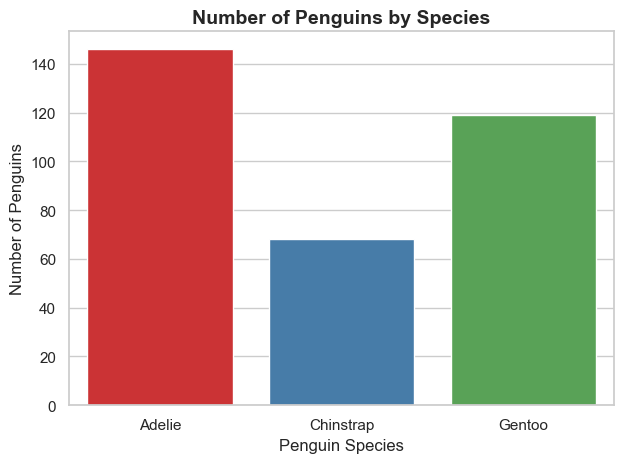

In [22]:
sns.countplot(data=df, x='species', palette='Set1')

plt.xlabel('Penguin Species')
plt.ylabel('Number of Penguins')
plt.title('Number of Penguins by Species', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### TASK 03

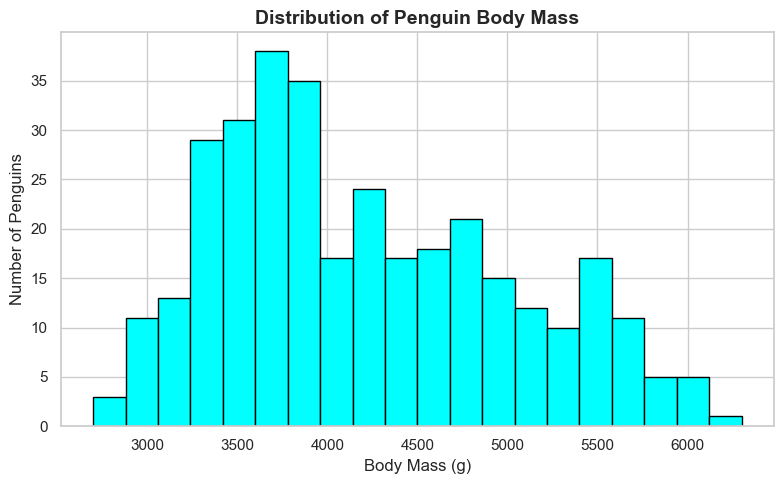

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(df['body_mass_g'], bins=20, color='cyan', edgecolor='black')

plt.xlabel('Body Mass (g)')
plt.ylabel('Number of Penguins')
plt.title('Distribution of Penguin Body Mass', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The distribution of body mass is slightly right-skewed, with most penguins having moderate body mass and a smaller number having higher body mass.

### TASK 04

C:\Users\Shoaib Ali Kori\AppData\Local\Temp\ipykernel_24032\481094586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='body_mass_g', palette='Set3')


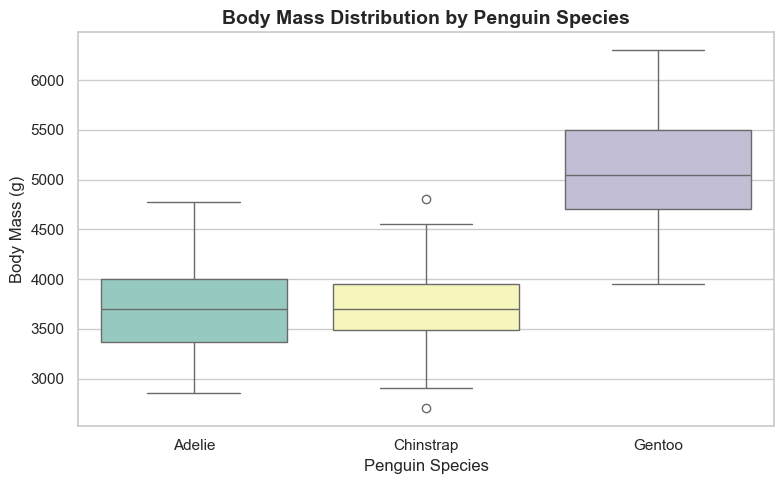

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='species', y='body_mass_g', palette='Set3')

plt.xlabel('Penguin Species')
plt.ylabel('Body Mass (g)')
plt.title('Body Mass Distribution by Penguin Species', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### TASK 05

In [17]:
for species in df['species'].unique():

    data = df[df['species'] == species]['body_mass_g']

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data < lower) | (data > upper)]

    print(species, ":", len(outliers), "outliers")

Adelie : 0 outliers
Chinstrap : 2 outliers
Gentoo : 0 outliers


### TASK 06

In [26]:
df['zscore'] = stats.zscore(df['body_mass_g'])

outliers_z = df[df['zscore'].abs() > 3]

print("Number of z-score outliers:", len(outliers_z))

Number of z-score outliers: 0


### TASK 07

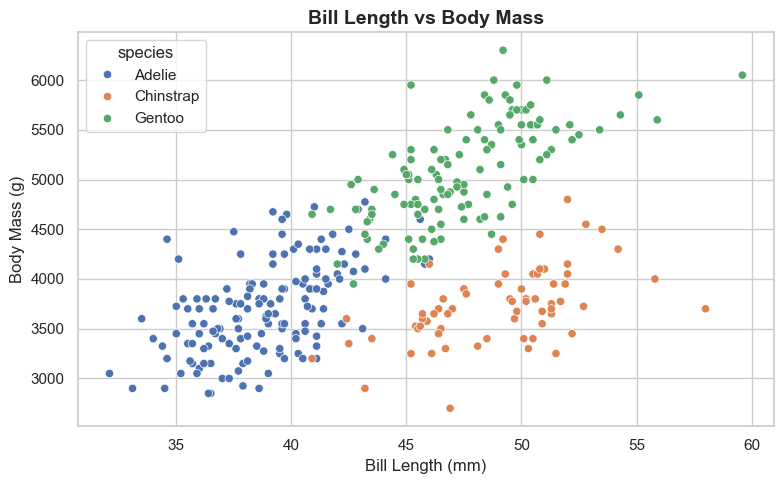

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='body_mass_g',
    hue='species'
)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Bill Length vs Body Mass', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

There appears to be a positive relationship between bill length and body mass. As bill length increases, body mass generally tends to increase. The points are colored by species to show differences between the three penguin species.

### TASK 08

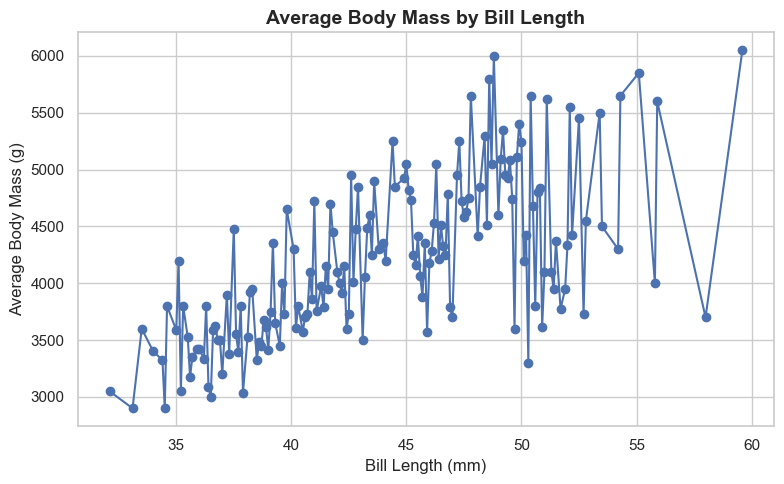

In [30]:
avg_body_mass = df.groupby('bill_length_mm')['body_mass_g'].mean().sort_index()

plt.figure(figsize=(8, 5))

plt.plot(avg_body_mass.index, avg_body_mass.values, marker='o')

plt.xlabel('Bill Length (mm)')
plt.ylabel('Average Body Mass (g)')
plt.title('Average Body Mass by Bill Length', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### AREA CHART

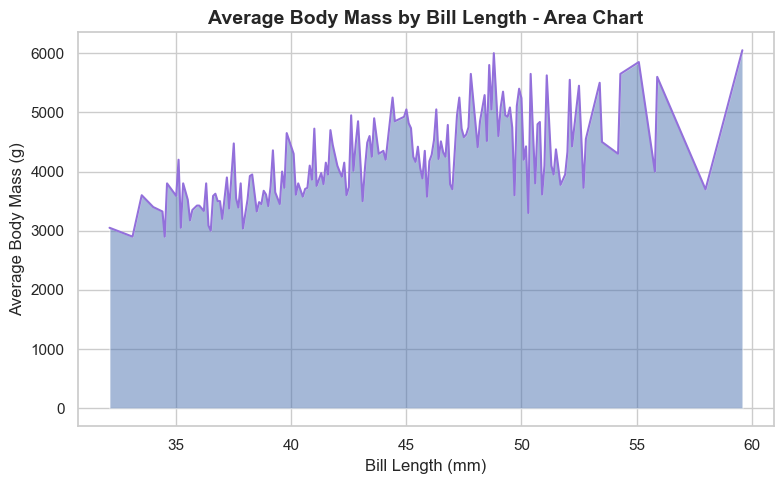

In [31]:
plt.figure(figsize=(8, 5))

plt.fill_between(avg_body_mass.index, avg_body_mass.values, alpha=0.5)

plt.plot(avg_body_mass.index, avg_body_mass.values, color='mediumpurple')

plt.xlabel('Bill Length (mm)')
plt.ylabel('Average Body Mass (g)')
plt.title('Average Body Mass by Bill Length - Area Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The line chart makes the trend in average body mass easier to follow because it focuses on the movement of the line. The area chart emphasizes the size of the average values because the area below the line is filled. Both charts show the same averages, but the area chart gives a stronger visual impression of the magnitude of the values.

### TASK 09

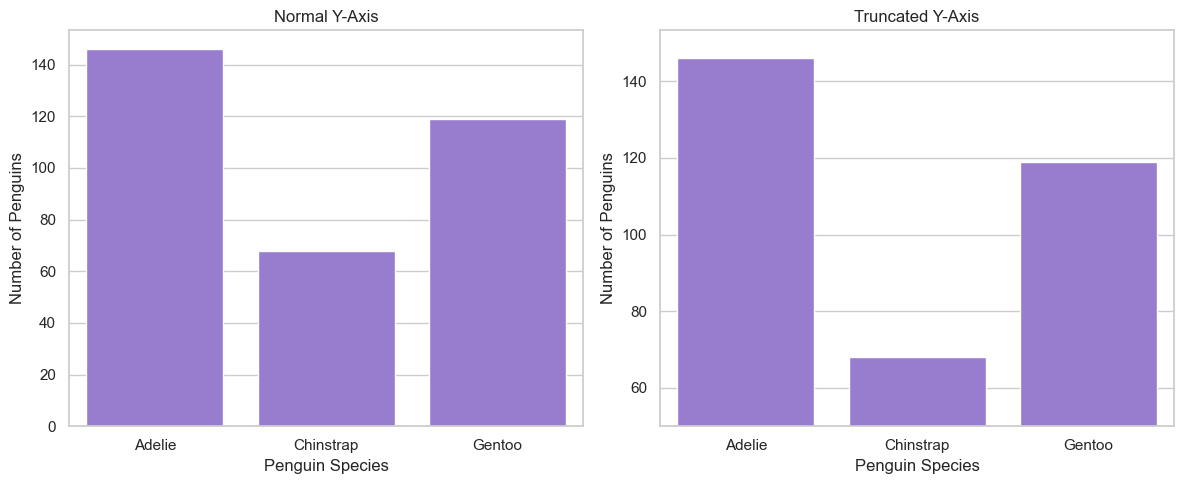

In [33]:
plt.figure(figsize=(12, 5))

# Normal bar chart
plt.subplot(1, 2, 1)

sns.countplot(data=df, x='species', color='mediumpurple')

plt.xlabel('Penguin Species')
plt.ylabel('Number of Penguins')
plt.title('Normal Y-Axis')
plt.ylim(bottom=0)


# Truncated y-axis
plt.subplot(1, 2, 2)

sns.countplot(data=df, x='species', color='mediumpurple')

plt.xlabel('Penguin Species')
plt.ylabel('Number of Penguins')
plt.title('Truncated Y-Axis')
plt.ylim(bottom=50)

plt.tight_layout()
plt.show()

The normal chart starting at zero gives a more accurate visual representation of the differences between the species. When the y-axis is truncated, the bars appear much more different in height, which can make the differences seem larger than they actually are. The underlying counts remain exactly the same; only the visual impression changes.